# RQ1 - Carbon-Aware ML Analysis

**Research question.** Which model family gives the strongest Pareto trade-off between predictive accuracy and estimated computational carbon for German next-day high-load-event classification?

This notebook is intentionally reproducible: it reads the raw `data.csv` if `preprocessed_content.csv` is absent, rebuilds the engineered dataset, and writes the publication-ready table and figure for RQ1.

Methodological steps:

1. Load the Germany-relevant OPSD hourly time-series variables.
2. Construct a next-day high-load target.
3. Use chronological evaluation: 2015-2018 for training and 2019-2020 for testing.
4. Save the result table as `outputs/tables/rq1_model_tradeoff_metrics.csv`.
5. Save the figure as `outputs/figures/rq1_accuracy_carbon_pareto.pdf` and a PNG companion for the report.


,model,n_train,n_test,accuracy,balanced_accuracy,precision,recall,f1_score,roc_auc,fit_time_s,predict_time_s,model_size_kb,energy_wh_proxy,training_carbon_mgco2e_proxy,mean_training_carbon_proxy_g_per_kwh,pareto_efficient,carbon_adjusted_score
0,Histogram Gradient Boosting,34897,15312,0.965452,0.950956,0.871360,0.929245,0.899372,0.993095,0.615981,0.087305,535.889648,0.008136,4.230154,519.911992,True,0.854111
1,Neural Network,34897,15312,0.965125,0.943992,0.881839,0.912343,0.896832,0.992681,1.083465,0.002509,33.511719,0.013556,7.047852,519.911992,False,0.858810
2,Random Forest,34897,15312,0.960162,0.959745,0.828242,0.959119,0.888889,0.993060,0.711173,0.027424,4746.983398,0.009027,4.693133,519.911992,False,0.833240
3,Logistic Regression,34897,15312,0.883098,0.905824,0.593595,0.939858,0.727632,0.968117,0.037561,0.002052,2.603516,0.000480,0.249442,519.911992,True,0.719647
4,Linear SVM,34897,15312,0.880421,0.904848,0.587442,0.941431,0.723456,0.967935,0.050359,0.001621,2.497070,0.000638,0.331489,519.911992,False,0.714910


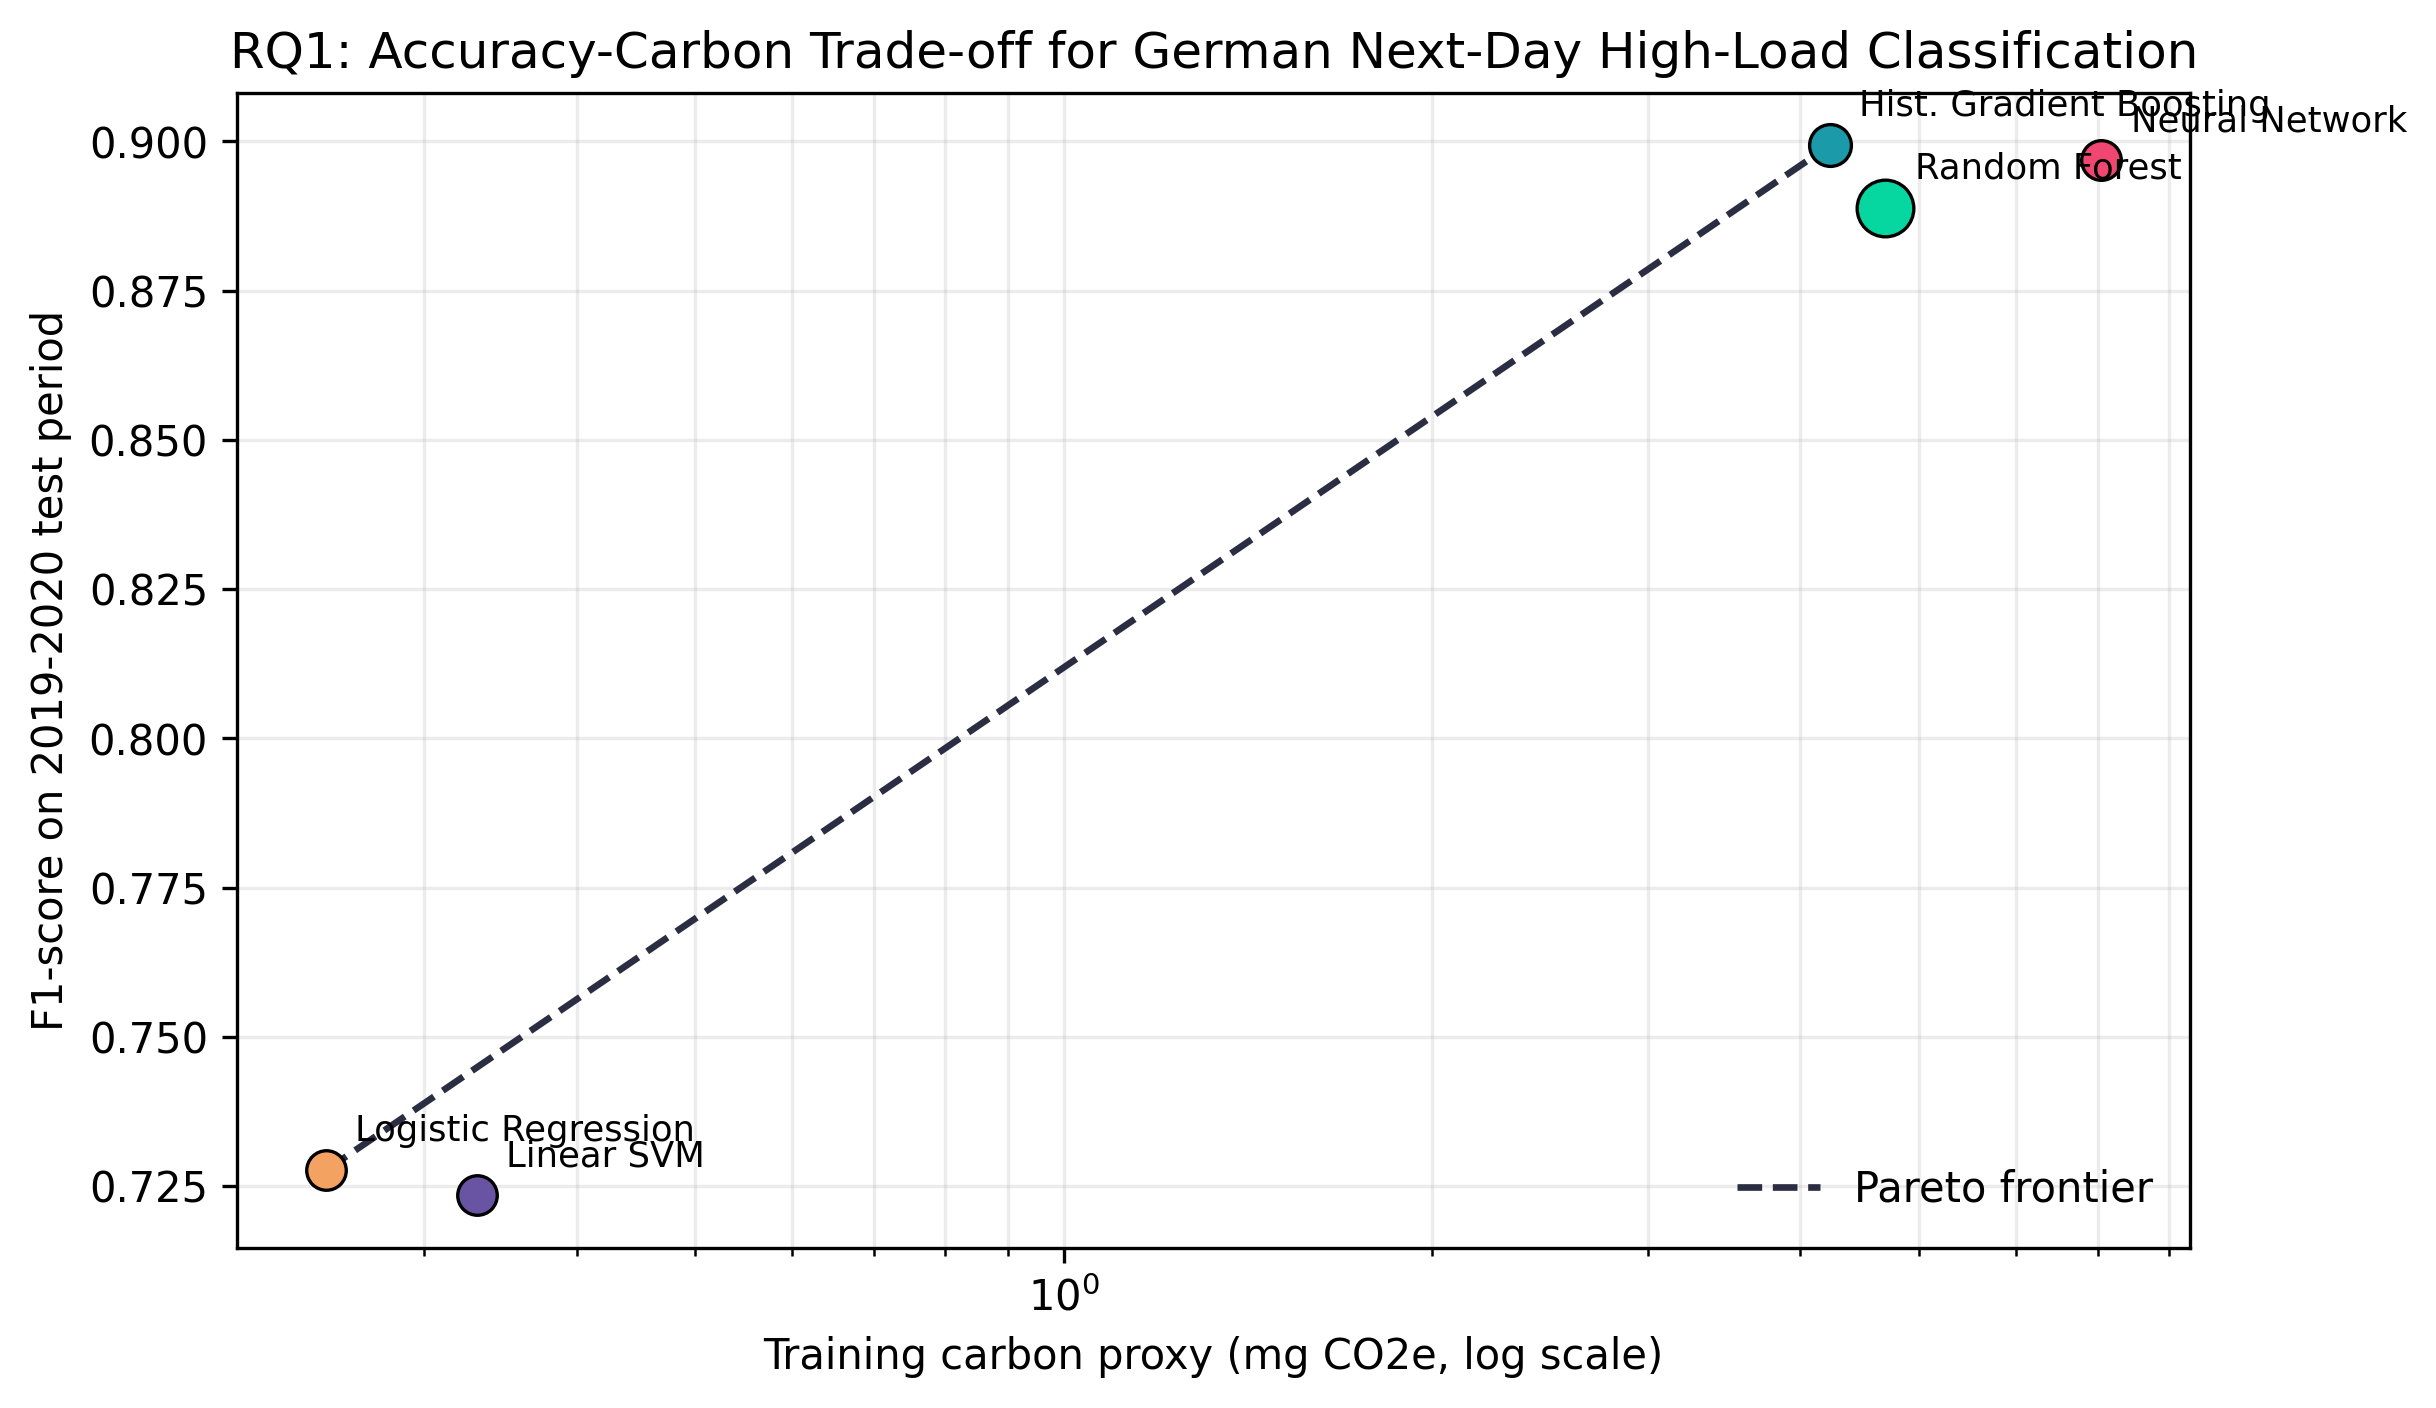

Saved table: outputs/tables/rq1_model_tradeoff_metrics.csv
Saved PDF figure: outputs/figures/rq1_accuracy_carbon_pareto.pdf


In [1]:
import sys
import time
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from scripts import generate_analysis_assets as assets

# Use existing preprocessing pipeline for consistency with the project artifacts
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TRAIN_CPU_WATTS = 45.0
INFER_CPU_WATTS = 18.0

CALENDAR_FEATURES = [
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "doy_sin",
    "doy_cos",
    "is_weekend",
]
LOAD_HISTORY_FEATURES = [
    "load_mw",
    "load_lag_1h",
    "load_lag_24h",
    "load_lag_168h",
    "load_roll_24h_mean",
    "load_roll_168h_mean",
    "load_roll_24h_std",
]
RENEWABLE_FEATURES = [
    "solar_generation_mw",
    "wind_generation_mw",
    "wind_onshore_generation_mw",
    "wind_offshore_generation_mw",
    "renewable_generation_mw",
    "renewable_share",
    "renewable_share_lag_24h",
    "residual_load_mw",
    "residual_load_share",
]
ZONE_FEATURES = [
    "zone_50hertz_load_mw",
    "zone_amprion_load_mw",
    "zone_tennet_load_mw",
    "zone_transnetbw_load_mw",
    "zone_load_imbalance_mw",
]
FORECAST_FEATURES = ["load_forecast_mw"]
ALL_FEATURES = (
    CALENDAR_FEATURES
    + LOAD_HISTORY_FEATURES
    + RENEWABLE_FEATURES
    + ZONE_FEATURES
    + FORECAST_FEATURES
)


def save_figure(fig: plt.Figure, stem: str) -> None:
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{stem}.{ext}", bbox_inches="tight", dpi=300, facecolor="white")
    plt.close(fig)


def train_test_split_time(df: pd.DataFrame, features: list[str]):
    train_mask = df["timestamp_utc"] < pd.Timestamp("2019-01-01", tz="UTC")
    test_mask = ~train_mask
    X_train = df.loc[train_mask, features].astype(float)
    X_test = df.loc[test_mask, features].astype(float)
    y_train = df.loc[train_mask, "target_high_load_next_24h"].astype(int)
    y_test = df.loc[test_mask, "target_high_load_next_24h"].astype(int)
    return X_train, X_test, y_train, y_test, df.loc[test_mask].copy()


def build_models() -> dict[str, object]:
    return {
        "Logistic Regression": make_pipeline(
            StandardScaler(),
            LogisticRegression(
                max_iter=2500,
                class_weight="balanced",
                solver="lbfgs",
                random_state=RANDOM_STATE,
            ),
        ),
        "Linear SVM": make_pipeline(
            StandardScaler(),
            LinearSVC(
                max_iter=6000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                dual="auto",
            ),
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=120,
            max_depth=14,
            min_samples_leaf=20,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "Histogram Gradient Boosting": HistGradientBoostingClassifier(
            max_iter=140,
            learning_rate=0.055,
            max_leaf_nodes=31,
            l2_regularization=0.05,
            random_state=RANDOM_STATE,
        ),
        "Neural Network": make_pipeline(
            StandardScaler(),
            MLPClassifier(
                hidden_layer_sizes=(32,),
                alpha=0.003,
                early_stopping=True,
                validation_fraction=0.12,
                max_iter=180,
                random_state=RANDOM_STATE,
            ),
        ),
    }


def predict_score(model, X: pd.DataFrame) -> np.ndarray:
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        score = model.decision_function(X)
        return 1 / (1 + np.exp(-np.clip(score, -30, 30)))
    return model.predict(X)


def model_size_kb(model) -> float:
    return len(pickle.dumps(model)) / 1024


def carbon_metrics(fit_time_s: float, pred_time_s: float, mean_proxy: float) -> tuple[float, float]:
    energy_wh = fit_time_s * TRAIN_CPU_WATTS / 3600 + pred_time_s * INFER_CPU_WATTS / 3600
    carbon_mg = energy_wh * mean_proxy
    return energy_wh, carbon_mg


def evaluate_models(df: pd.DataFrame, features: list[str], model_dict: dict[str, object] | None = None):
    if model_dict is None:
        model_dict = build_models()

    X_train, X_test, y_train, y_test, test_df = train_test_split_time(df, features)
    rows = []
    fitted = {}
    mean_proxy = float(
        df.loc[
            df["timestamp_utc"] < pd.Timestamp("2019-01-01", tz="UTC"),
            "carbon_intensity_proxy_g_per_kwh",
        ].mean()
    )

    for name, model in model_dict.items():
        t0 = time.perf_counter()
        model.fit(X_train, y_train)
        fit_time = time.perf_counter() - t0

        t1 = time.perf_counter()
        y_pred = model.predict(X_test)
        y_score = predict_score(model, X_test)
        pred_time = time.perf_counter() - t1

        energy_wh, carbon_mg = carbon_metrics(fit_time, pred_time, mean_proxy)
        rows.append(
            {
                "model": name,
                "n_train": int(len(X_train)),
                "n_test": int(len(X_test)),
                "accuracy": accuracy_score(y_test, y_pred),
                "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
                "precision": precision_score(y_test, y_pred, zero_division=0),
                "recall": recall_score(y_test, y_pred, zero_division=0),
                "f1_score": f1_score(y_test, y_pred, zero_division=0),
                "roc_auc": roc_auc_score(y_test, y_score),
                "fit_time_s": fit_time,
                "predict_time_s": pred_time,
                "model_size_kb": model_size_kb(model),
                "energy_wh_proxy": energy_wh,
                "training_carbon_mgco2e_proxy": carbon_mg,
                "mean_training_carbon_proxy_g_per_kwh": mean_proxy,
            }
        )
        fitted[name] = model

    metrics = pd.DataFrame(rows).sort_values("f1_score", ascending=False)
    return metrics, fitted, test_df, y_test


def mark_pareto(metrics: pd.DataFrame) -> pd.DataFrame:
    out = metrics.copy()
    efficient = []
    for _, row in out.iterrows():
        dominated = (
            (out["f1_score"] >= row["f1_score"])
            & (out["training_carbon_mgco2e_proxy"] <= row["training_carbon_mgco2e_proxy"])
            & (
                (out["f1_score"] > row["f1_score"])
                | (out["training_carbon_mgco2e_proxy"] < row["training_carbon_mgco2e_proxy"])
            )
        ).any()
        efficient.append(not dominated)

    out["pareto_efficient"] = efficient
    out["carbon_adjusted_score"] = (
        out["f1_score"]
        - 0.025 * np.log10(1 + out["training_carbon_mgco2e_proxy"])
        - 0.010 * np.log10(1 + out["model_size_kb"])
    )
    return out


def run_rq1_inline(df: pd.DataFrame) -> pd.DataFrame:
    metrics, _, _, _ = evaluate_models(df, ALL_FEATURES)
    metrics = mark_pareto(metrics)
    metrics.to_csv(TABLE_DIR / "rq1_model_tradeoff_metrics.csv", index=False)

    fig, ax = plt.subplots(figsize=(8.4, 5.0))
    colors = ["#1b9aaa", "#ef476f", "#06d6a0", "#f4a261", "#6954a3"]

    for idx, row in metrics.reset_index(drop=True).iterrows():
        ax.scatter(
            row["training_carbon_mgco2e_proxy"],
            row["f1_score"],
            s=90 + 0.02 * row["model_size_kb"],
            color=colors[idx % len(colors)],
            edgecolor="black",
            linewidth=0.8,
            zorder=3,
        )
        label = row["model"].replace("Histogram ", "Hist. ")
        ax.annotate(
            label,
            (row["training_carbon_mgco2e_proxy"], row["f1_score"]),
            textcoords="offset points",
            xytext=(7, 7),
            fontsize=8.5,
        )

    frontier = metrics[metrics["pareto_efficient"]].sort_values("training_carbon_mgco2e_proxy")
    if len(frontier) > 1:
        ax.plot(
            frontier["training_carbon_mgco2e_proxy"],
            frontier["f1_score"],
            color="#2b2d42",
            linewidth=1.6,
            linestyle="--",
            label="Pareto frontier",
        )

    ax.set_xscale("log")
    ax.set_xlabel("Training carbon proxy (mg CO2e, log scale)")
    ax.set_ylabel("F1-score on 2019-2020 test period")
    ax.set_title("RQ1: Accuracy-Carbon Trade-off for German Next-Day High-Load Classification")
    ax.grid(True, which="both", alpha=0.24)
    ax.legend(frameon=False, loc="lower right")
    save_figure(fig, "rq1_accuracy_carbon_pareto")

    return metrics


df = assets.load_or_create_preprocessed()
result = run_rq1_inline(df)

# Display saved artifacts in the executed notebook for GitHub review.
table_dir = PROJECT_ROOT / "outputs" / "tables"
figure_dir = PROJECT_ROOT / "outputs" / "figures"
table_path = table_dir / "rq1_model_tradeoff_metrics.csv"
figure_path = figure_dir / "rq1_accuracy_carbon_pareto.png"
pdf_path = figure_dir / "rq1_accuracy_carbon_pareto.pdf"
display(pd.read_csv(table_path).head())
display(Image(filename=str(figure_path)))
print(f"Saved table: {table_path.relative_to(PROJECT_ROOT)}")
print(f"Saved PDF figure: {pdf_path.relative_to(PROJECT_ROOT)}")
